In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
PJME_data = pd.read_csv(
    "PJME_phase2_preprocessed.csv",
    parse_dates=["Datetime"]
)

In [4]:
PJME_data = PJME_data.set_index("Datetime")

# Sort chronologically
PJME_data = PJME_data.sort_index()

print(PJME_data.shape)
print(PJME_data.head())

(145224, 15)
                     PJME_MW  Hour  Day  Week  Month  DayOfWeek  IsWeekend  \
Datetime                                                                     
2002-01-08 01:00:00  29445.0     1    8     2      1          1          0   
2002-01-08 02:00:00  28670.0     2    8     2      1          1          0   
2002-01-08 03:00:00  28375.0     3    8     2      1          1          0   
2002-01-08 04:00:00  28542.0     4    8     2      1          1          0   
2002-01-08 05:00:00  29261.0     5    8     2      1          1          0   

                       Lag_1   Lag_24   Lag_48  Lag_168  Rolling_Mean_24  \
Datetime                                                                   
2002-01-08 01:00:00  31187.0  26862.0  27100.0  30393.0     33452.583333   
2002-01-08 02:00:00  29445.0  25976.0  26097.0  29265.0     33560.208333   
2002-01-08 03:00:00  28670.0  25641.0  25793.0  28357.0     33672.458333   
2002-01-08 04:00:00  28375.0  25666.0  25657.0  27899.0     

In [5]:
# Make sure data is chronological
PJME_data = PJME_data.sort_index()

n = len(PJME_data)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train = PJME_data.iloc[:train_end].copy()
validation = PJME_data.iloc[train_end:val_end].copy()
test = PJME_data.iloc[val_end:].copy()

print("Train:", train.shape)
print("Validation:", validation.shape)
print("Test:", test.shape)

print("\nTrain period:")
print(train.index.min(), "to", train.index.max())

print("\nValidation period:")
print(validation.index.min(), "to", validation.index.max())

print("\nTest period:")
print(test.index.min(), "to", test.index.max())

Train: (101656, 15)
Validation: (21784, 15)
Test: (21784, 15)

Train period:
2002-01-08 01:00:00 to 2013-08-13 16:00:00

Validation period:
2013-08-13 17:00:00 to 2016-02-07 08:00:00

Test period:
2016-02-07 09:00:00 to 2018-08-03 00:00:00


In [6]:
features = [
    "PJME_MW",
    "Hour",
    "Day",
    "Week",
    "Month",
    "DayOfWeek",
    "IsWeekend",
    "Lag_1",
    "Lag_24",
    "Lag_48",
    "Lag_168",
    "Rolling_Mean_24",
    "Rolling_Mean_168",
    "Rolling_Std_24",
    "Rolling_Std_168"
]

target = "PJME_MW"

X_train = train[features].copy()
X_val = validation[features].copy()
X_test = test[features].copy()

y_train = train[target].copy()
y_val = validation[target].copy()
y_test = test[target].copy()

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (101656, 15)
X_val: (21784, 15)
X_test: (21784, 15)


In [7]:
from sklearn.preprocessing import StandardScaler

feature_scaler = StandardScaler()
target_scaler = StandardScaler()

X_train_scaled = feature_scaler.fit_transform(X_train)
X_val_scaled = feature_scaler.transform(X_val)
X_test_scaled = feature_scaler.transform(X_test)

y_train_scaled = target_scaler.fit_transform(
    y_train.values.reshape(-1, 1)
)

y_val_scaled = target_scaler.transform(
    y_val.values.reshape(-1, 1)
)

y_test_scaled = target_scaler.transform(
    y_test.values.reshape(-1, 1)
)

print("Scaling completed.")

Scaling completed.


In [12]:
def create_sequences(X, y, input_steps=168, output_steps=24):
    X_seq = []
    y_seq = []

    for i in range(input_steps, len(X) - output_steps + 1):
        X_seq.append(
            X[i-input_steps:i]
        )

        y_seq.append(
            y[i:i+output_steps].flatten()
        )

    return np.array(X_seq), np.array(y_seq)


X_train_seq, y_train_seq = create_sequences(
    X_train_scaled,
    y_train_scaled,
    input_steps=168,
    output_steps=24
)

X_val_seq, y_val_seq = create_sequences(
    X_val_scaled,
    y_val_scaled,
    input_steps=168,
    output_steps=24
)

X_test_seq, y_test_seq = create_sequences(
    X_test_scaled,
    y_test_scaled,
    input_steps=168,
    output_steps=24
)

print("X_train:", X_train_seq.shape)
print("y_train:", y_train_seq.shape)

print("X_val:", X_val_seq.shape)
print("y_val:", y_val_seq.shape)

print("X_test:", X_test_seq.shape)
print("y_test:", y_test_seq.shape)

X_train: (101465, 168, 15)
y_train: (101465, 24)
X_val: (21593, 168, 15)
y_val: (21593, 24)
X_test: (21593, 168, 15)
y_test: (21593, 24)


In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [14]:


rnn_model = Sequential([
    SimpleRNN(
        64,
        input_shape=(168, 15),
        return_sequences=False
    ),

    Dropout(0.2),

    Dense(64, activation="relu"),

    Dense(24)
])

rnn_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,840 (42.34 KB)

 Trainable params: 10,840 (42.34 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
rnn_history = rnn_model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=15,
    batch_size=64,
    verbose=1
)

Epoch 1/15
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 38s 23ms/step - loss: 0.1608 - mae: 0.2966 - val_loss: 0.0971 - val_mae: 0.2290
Epoch 2/15
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 37s 21ms/step - loss: 0.0994 - mae: 0.2342 - val_loss: 0.0872 - val_mae: 0.2119
Epoch 3/15
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 43s 22ms/step - loss: 0.0914 - mae: 0.2229 - val_loss: 0.0855 - val_mae: 0.2066
Epoch 4/15
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 34s 21ms/step - loss: 0.0879 - mae: 0.2180 - val_loss: 0.0845 - val_mae: 0.2106
Epoch 5/15
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 40s 21ms/step - loss: 0.0851 - mae: 0.2139 - val_loss: 0.0809 - val_mae: 0.2034
Epoch 6/15
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - loss: 0.0836 - mae: 0.2117 - val_loss: 0.0788 - val_mae: 0.2006
Epoch 7/15
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 34s 21ms/step - loss: 0.0825 - mae: 0.2101 - val_loss: 0.0801 - val_mae: 0.2046
Epoch 8/15
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - loss: 0.0810 - mae: 0.2080 - val_loss: 0.0815 - val_mae: 0.2065
Epoch 9/15
1586/1586 ━━━

In [17]:
import os

os.makedirs("images", exist_ok=True)
os.makedirs("models/phase5", exist_ok=True)

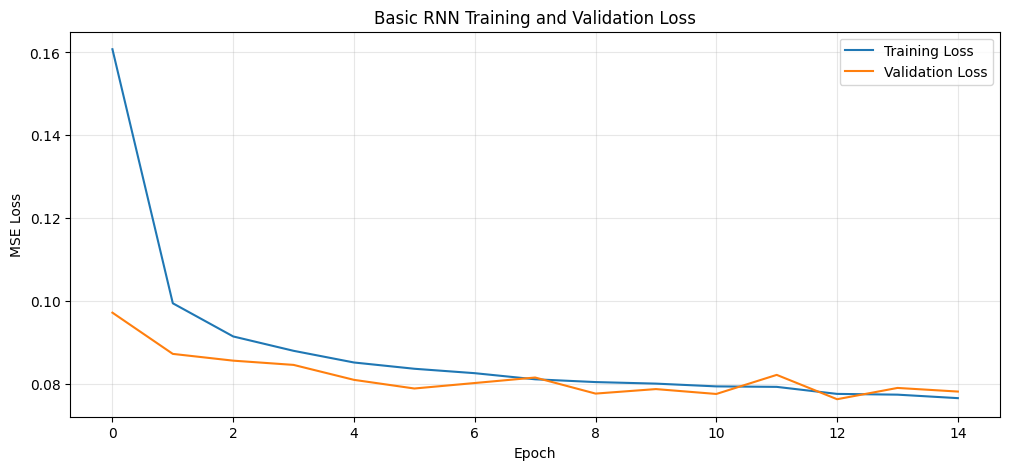

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 5))

plt.plot(
    rnn_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    rnn_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Basic RNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    "images/phase5_rnn_training.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
rnn_pred_scaled = rnn_model.predict(
    X_test_seq,
    batch_size=64
)

print("Prediction shape:", rnn_pred_scaled.shape)

338/338 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step
Prediction shape: (21593, 24)


In [19]:
rnn_pred = target_scaler.inverse_transform(
    rnn_pred_scaled.reshape(-1, 1)
).reshape(rnn_pred_scaled.shape)

rnn_actual = target_scaler.inverse_transform(
    y_test_seq.reshape(-1, 1)
).reshape(y_test_seq.shape)

print("Prediction shape:", rnn_pred.shape)
print("Actual shape:", rnn_actual.shape)

Prediction shape: (21593, 24)
Actual shape: (21593, 24)


In [8]:
# CREATE EVALUATION FUNCTION
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

def evaluate_model(actual, predicted):

    mae = mean_absolute_error(actual, predicted)

    rmse = np.sqrt(
        mean_squared_error(actual, predicted)
    )

    mape = np.mean(
        np.abs((actual - predicted) / actual)
    ) * 100

    r2 = r2_score(actual, predicted)

    bias = np.mean(predicted - actual)

    return mae, rmse, mape, r2, bias

In [22]:
# evaluate rnn
rnn_mae = mean_absolute_error(
    rnn_actual.flatten(),
    rnn_pred.flatten()
)

rnn_rmse = np.sqrt(
    mean_squared_error(
        rnn_actual.flatten(),
        rnn_pred.flatten()
    )
)

rnn_mape = np.mean(
    np.abs(
        (rnn_actual.flatten() - rnn_pred.flatten())
        / rnn_actual.flatten()
    )
) * 100

rnn_r2 = r2_score(
    rnn_actual.flatten(),
    rnn_pred.flatten()
)

rnn_bias = np.mean(
    rnn_pred.flatten() - rnn_actual.flatten()
)

print("========== RNN RESULTS ==========")
print("MAE :", rnn_mae)
print("RMSE:", rnn_rmse)
print("MAPE:", rnn_mape)
print("R²  :", rnn_r2)
print("Bias:", rnn_bias)

========== RNN RESULTS ==========
MAE : 1430.2133220007822
RMSE: 1981.7279488063964
MAPE: 4.582684822640543
R²  : 0.9053238845459299
Bias: 375.384035532258


In [23]:
rnn_model.save("models/phase5/rnn_24h.keras")

In [25]:
import json

with open("models/phase5/rnn_model.json", "w") as f:
    json.dump(rnn_history.history, f)

In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

lstm_model = Sequential([
    LSTM(
        64,
        input_shape=(168, 15),
        return_sequences=False
    ),

    Dropout(0.2),

    Dense(64, activation="relu"),

    Dense(24)
])

lstm_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        20,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,200 (102.34 KB)

 Trainable params: 26,200 (102.34 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
lstm_history = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=15,
    batch_size=64,
    verbose=1
)

Epoch 1/15
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 111s 68ms/step - loss: 0.1435 - mae: 0.2774 - val_loss: 0.0911 - val_mae: 0.2223
Epoch 2/15
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 137s 65ms/step - loss: 0.0906 - mae: 0.2234 - val_loss: 0.0853 - val_mae: 0.2109
Epoch 3/15
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 94s 59ms/step - loss: 0.0837 - mae: 0.2136 - val_loss: 0.0825 - val_mae: 0.2080
Epoch 4/15
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 140s 58ms/step - loss: 0.0793 - mae: 0.2075 - val_loss: 0.0833 - val_mae: 0.2087
Epoch 5/15
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 92s 58ms/step - loss: 0.0763 - mae: 0.2033 - val_loss: 0.0792 - val_mae: 0.2011
Epoch 6/15
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 91s 57ms/step - loss: 0.0731 - mae: 0.1989 - val_loss: 0.0851 - val_mae: 0.2074
Epoch 7/15
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 145s 59ms/step - loss: 0.0711 - mae: 0.1963 - val_loss: 0.0783 - val_mae: 0.1985
Epoch 8/15
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 137s 56ms/step - loss: 0.0690 - mae: 0.1935 - val_loss: 0.0827 - val_mae: 0.2015
Epoch 9/15
1586/158

In [28]:
lstm_pred_scaled = lstm_model.predict(
    X_test_seq,
    batch_size=64
)
print("Prediction shape:", lstm_pred_scaled.shape)

338/338 ━━━━━━━━━━━━━━━━━━━━ 13s 38ms/step
Prediction shape: (21593, 24)


In [29]:
lstm_pred = target_scaler.inverse_transform(
    lstm_pred_scaled.reshape(-1, 1)
).reshape(lstm_pred_scaled.shape)

lstm_actual = target_scaler.inverse_transform(
    y_test_seq.reshape(-1, 1)
).reshape(y_test_seq.shape)

In [30]:
lstm_mae = mean_absolute_error(
    lstm_actual.flatten(),
    lstm_pred.flatten()
)

lstm_rmse = np.sqrt(
    mean_squared_error(
        lstm_actual.flatten(),
        lstm_pred.flatten()
    )
)

lstm_mape = np.mean(
    np.abs(
        (lstm_actual.flatten() - lstm_pred.flatten())
        / lstm_actual.flatten()
    )
) * 100

lstm_r2 = r2_score(
    lstm_actual.flatten(),
    lstm_pred.flatten()
)

lstm_bias = np.mean(
    lstm_pred.flatten() - lstm_actual.flatten()
)

print("========== LSTM RESULTS ==========")
print("MAE :", lstm_mae)
print("RMSE:", lstm_rmse)
print("MAPE:", lstm_mape)
print("R²  :", lstm_r2)
print("Bias:", lstm_bias)

========== LSTM RESULTS ==========
MAE : 1539.1091036484686
RMSE: 2171.0322859555713
MAPE: 4.9120441764824285
R²  : 0.8863721142778263
Bias: 447.83148694518695


In [31]:
lstm_model.save("models/phase5/lstm_24h.keras")

In [32]:
import json

with open("models/phase5/lstm_model.json", "w") as f:
    json.dump(lstm_history.history, f)

In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense

gru_model = Sequential([
    GRU(
        64,
        input_shape=(168, 15),
        return_sequences=False
    ),

    Dense(64, activation="relu"),

    Dense(24)
])

gru_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

gru_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        15,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,272 (83.09 KB)

 Trainable params: 21,272 (83.09 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
gru_history = gru_model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=15,
    batch_size=64,
    verbose=1
)

Epoch 1/15
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 127s 79ms/step - loss: 0.1197 - mae: 0.2467 - val_loss: 0.0853 - val_mae: 0.2132
Epoch 2/15
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 126s 80ms/step - loss: 0.0713 - mae: 0.1911 - val_loss: 0.0802 - val_mae: 0.2018
Epoch 3/15
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 125s 79ms/step - loss: 0.0659 - mae: 0.1822 - val_loss: 0.0789 - val_mae: 0.1993
Epoch 4/15
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 148s 93ms/step - loss: 0.0629 - mae: 0.1773 - val_loss: 0.0783 - val_mae: 0.2001
Epoch 5/15
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 219s 104ms/step - loss: 0.0603 - mae: 0.1731 - val_loss: 0.0766 - val_mae: 0.1959
Epoch 6/15
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 140s 88ms/step - loss: 0.0582 - mae: 0.1700 - val_loss: 0.0764 - val_mae: 0.1950
Epoch 7/15
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 134s 83ms/step - loss: 0.0564 - mae: 0.1672 - val_loss: 0.0727 - val_mae: 0.1897
Epoch 8/15
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 128s 81ms/step - loss: 0.0547 - mae: 0.1646 - val_loss: 0.0741 - val_mae: 0.1906
Epoch 9/15
1586

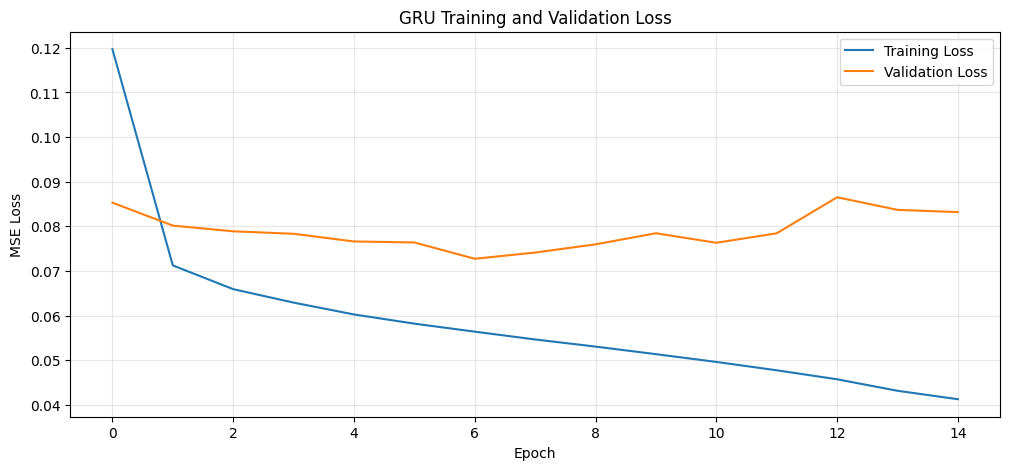

In [35]:
plt.figure(figsize=(12, 5))

plt.plot(
    gru_history.history["loss"],
    label="Training Loss"
)
plt.plot(
    gru_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("GRU Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    "images/phase5_gru_training.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [36]:
gru_pred_scaled = gru_model.predict(
    X_test_seq,
    batch_size=64
)
print("Prediction shape:", gru_pred_scaled.shape)

338/338 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step
Prediction shape: (21593, 24)


In [37]:
gru_pred = target_scaler.inverse_transform(
    gru_pred_scaled.reshape(-1, 1)
).reshape(gru_pred_scaled.shape)

gru_actual = target_scaler.inverse_transform(
    y_test_seq.reshape(-1, 1)
).reshape(y_test_seq.shape)

In [38]:
gru_mae = mean_absolute_error(
    gru_actual.flatten(),
    gru_pred.flatten()
)

gru_rmse = np.sqrt(
    mean_squared_error(
        gru_actual.flatten(),
        gru_pred.flatten()
    )
)

gru_mape = np.mean(
    np.abs(
        (gru_actual.flatten() - gru_pred.flatten())
        / gru_actual.flatten()
    )
) * 100

gru_r2 = r2_score(
    gru_actual.flatten(),
    gru_pred.flatten()
)

gru_bias = np.mean(
    gru_pred.flatten() - gru_actual.flatten()
)

print("========== GRU RESULTS ==========")
print("MAE :", gru_mae)
print("RMSE:", gru_rmse)
print("MAPE:", gru_mape)
print("R²  :", gru_r2)
print("Bias:", gru_bias)

========== GRU RESULTS ==========
MAE : 1452.6757279173771
RMSE: 2075.132045638438
MAPE: 4.598523493680257
R²  : 0.8961888896859629
Bias: 284.29167971810284


In [39]:
gru_model.save("models/phase5/gru_168_24h.keras")

In [40]:
import json

with open("models/phase5/gru_168_24h.json", "w") as f:
    json.dump(gru_history.history, f)

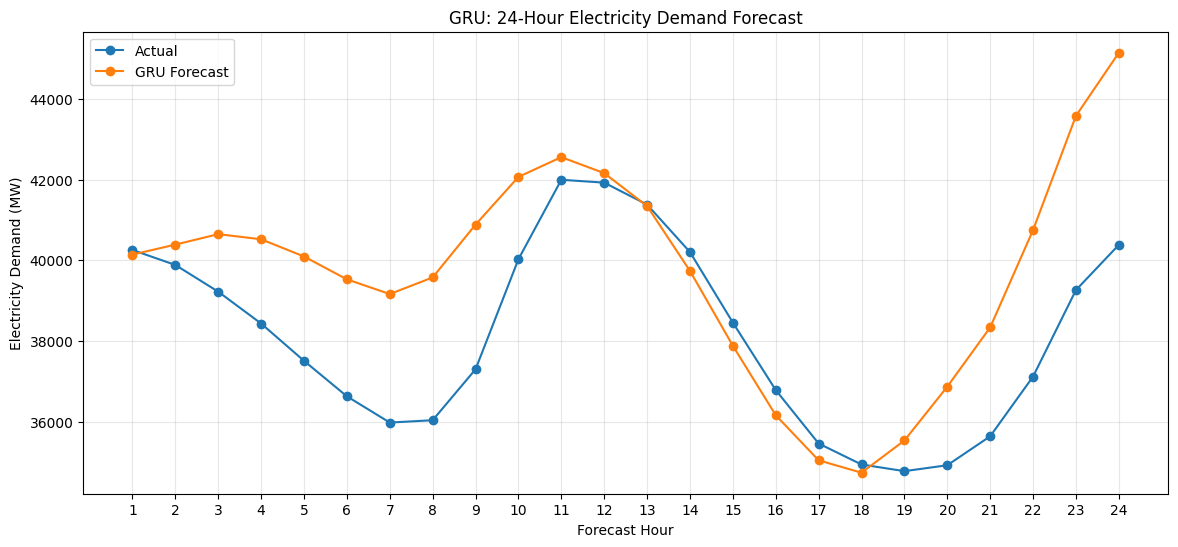

In [41]:
# 24 Hour Forecast visualization
plt.figure(figsize=(14, 6))

plt.plot(
    range(1, 25),
    gru_actual[0],
    marker="o",
    label="Actual"
)

plt.plot(
    range(1, 25),
    gru_pred[0],
    marker="o",
    label="GRU Forecast"
)

plt.title("GRU: 24-Hour Electricity Demand Forecast")
plt.xlabel("Forecast Hour")
plt.ylabel("Electricity Demand (MW)")
plt.xticks(range(1, 25))
plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    "images/phase5_gru_24hour_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [42]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense

bilstm_model = Sequential([

    Bidirectional(
        LSTM(
            64,
            return_sequences=False
        ),
        input_shape=(168, 15)
    ),

    Dense(64, activation="relu"),

    Dense(24)
])

bilstm_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

bilstm_model.summary()


# ============================================================
# Training
# ============================================================

bilstm_history = bilstm_model.fit(

    X_train_seq,

    y_train_seq,

    validation_data=(
        X_val_seq,
        y_val_seq
    ),

    epochs=15,

    batch_size=64,

    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 128)            │        40,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,776 (198.34 KB)

 Trainable params: 50,776 (198.34 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 162s 100ms/step - loss: 0.1014 - mae: 0.2248 - val_loss: 0.0883 - val_mae: 0.2157
Epoch 2/15
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 170s 107ms/step - loss: 0.0657 - mae: 0.1827 - val_loss: 0.0819 - val_mae: 0.2047
Epoch 3/15
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 200s 106ms/step - loss: 0.0594 - mae: 0.1728 - val_loss: 0.0834 - val_mae: 0.2077
Epoch 4/15
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 187s 118ms/step - loss: 0.0544 - mae: 0.1653 - val_loss: 0.0785 - val_mae: 0.2022
Epoch 5/15
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 221s 130ms/step - loss: 0.0498 - mae: 0.1590 - val_loss: 0.0811 - val_mae: 0.1997
Epoch 6/15
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 229s 109ms/step - loss: 0.0445 - mae: 0.1515 - val_loss: 0.0862 - val_mae: 0.2060
Epoch 7/15
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 198s 107ms/step - loss: 0.0395 - mae: 0.1442 - val_loss: 0.0885 - val_mae: 0.2053
Epoch 8/15
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 188s 98ms/step - loss: 0.0352 - mae: 0.1374 - val_loss: 0.0924 - val_mae: 0.2105
Epoch 9/1

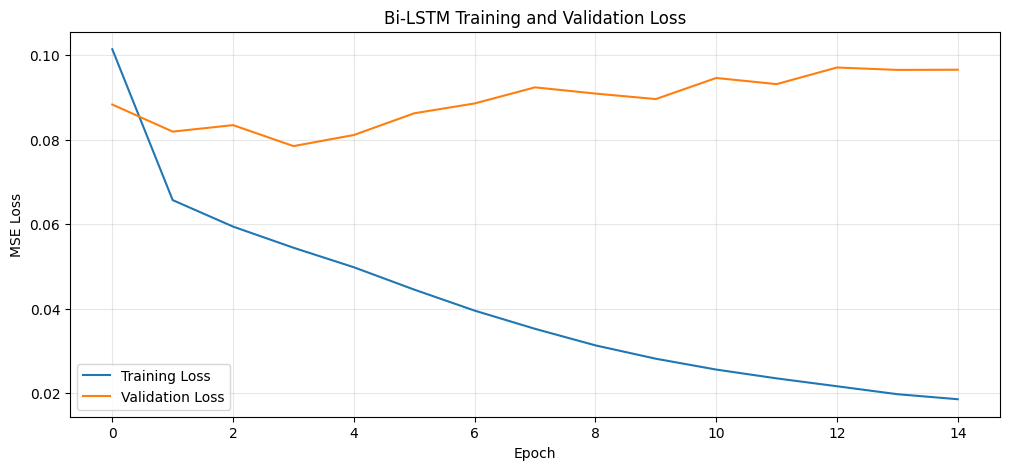

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    bilstm_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    bilstm_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Bi-LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    "images/phase5_bilstm_training.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [44]:
bilstm_pred_scaled = bilstm_model.predict(
    X_test_seq,
    batch_size=64
)

print(
    "Prediction shape:",
    bilstm_pred_scaled.shape
)

338/338 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step
Prediction shape: (21593, 24)


In [45]:
bilstm_pred = target_scaler.inverse_transform(
    bilstm_pred_scaled.reshape(-1, 1)
).reshape(bilstm_pred_scaled.shape)


bilstm_actual = target_scaler.inverse_transform(
    y_test_seq.reshape(-1, 1)
).reshape(y_test_seq.shape)

In [46]:
bilstm_mae = mean_absolute_error(
    bilstm_actual.flatten(),
    bilstm_pred.flatten()
)


bilstm_rmse = np.sqrt(
    mean_squared_error(
        bilstm_actual.flatten(),
        bilstm_pred.flatten()
    )
)


# Avoid division by zero for MAPE
actual_flat = bilstm_actual.flatten()
pred_flat = bilstm_pred.flatten()

non_zero = actual_flat != 0

bilstm_mape = np.mean(
    np.abs(
        (actual_flat[non_zero] - pred_flat[non_zero])
        / actual_flat[non_zero]
    )
) * 100


bilstm_r2 = r2_score(
    bilstm_actual.flatten(),
    bilstm_pred.flatten()
)


bilstm_bias = np.mean(
    bilstm_pred.flatten()
    - bilstm_actual.flatten()
)


# ============================================================
# Display Results
# ============================================================

print("========== BI-LSTM RESULTS ==========")
print("MAE :", bilstm_mae)
print("RMSE:", bilstm_rmse)
print("MAPE:", bilstm_mape)
print("R²  :", bilstm_r2)
print("Bias:", bilstm_bias)

========== BI-LSTM RESULTS ==========
MAE : 1557.6657932493313
RMSE: 2229.9810757314744
MAPE: 4.928703239175246
R²  : 0.8801177965194642
Bias: 369.85794581685906


In [47]:
bilstm_model.save("models/phase5/bilstm_168_24h.keras")

In [48]:
import json

with open("models/phase5/bilstm_168_24h.json", "w") as f:
    json.dump(bilstm_history.history, f)

# 48 hoursr -- 24 hours

In [12]:
def create_sequences(X, y, input_steps=48, output_steps=24):
    X_seq = []
    y_seq = []

    for i in range(input_steps, len(X) - output_steps + 1):

        X_seq.append(
            X[i-input_steps:i]
        )

        y_seq.append(
            y[i:i+output_steps].flatten()
        )

    return np.array(X_seq), np.array(y_seq)


X_train_seq, y_train_seq = create_sequences(
    X_train_scaled,
    y_train_scaled,
    input_steps=48,
    output_steps=24
)

X_val_seq, y_val_seq = create_sequences(
    X_val_scaled,
    y_val_scaled,
    input_steps=48,
    output_steps=24
)

X_test_seq, y_test_seq = create_sequences(
    X_test_scaled,
    y_test_scaled,
    input_steps=48,
    output_steps=24
)

print("X_train:", X_train_seq.shape)
print("y_train:", y_train_seq.shape)

print("X_val:", X_val_seq.shape)
print("y_val:", y_val_seq.shape)

print("X_test:", X_test_seq.shape)
print("y_test:", y_test_seq.shape)

X_train: (101585, 48, 15)
y_train: (101585, 24)
X_val: (21713, 48, 15)
y_val: (21713, 24)
X_test: (21713, 48, 15)
y_test: (21713, 24)


**RNN model**

In [13]:
rnn_model_48 = Sequential([

    SimpleRNN(
        64,
        input_shape=(48, X_train_seq.shape[2]),
        return_sequences=False
    ),

    Dense(64, activation="relu"),

    # Predict next 24 hours
    Dense(24)
])

rnn_model_48.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

rnn_model_48.summary()




/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,840 (42.34 KB)

 Trainable params: 10,840 (42.34 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
rnn_history_48 = rnn_model_48.fit(

    X_train_seq,
    y_train_seq,

    validation_data=(
        X_val_seq,
        y_val_seq
    ),

    epochs=15,

    batch_size=64,

    verbose=1
)


Epoch 1/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 0.1306 - mae: 0.2572 - val_loss: 0.0950 - val_mae: 0.2225
Epoch 2/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.0773 - mae: 0.2000 - val_loss: 0.0902 - val_mae: 0.2137
Epoch 3/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.0714 - mae: 0.1904 - val_loss: 0.0830 - val_mae: 0.2052
Epoch 4/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.0683 - mae: 0.1852 - val_loss: 0.0803 - val_mae: 0.2034
Epoch 5/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.0665 - mae: 0.1823 - val_loss: 0.0807 - val_mae: 0.2018
Epoch 6/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.0650 - mae: 0.1797 - val_loss: 0.0805 - val_mae: 0.2015
Epoch 7/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.0639 - mae: 0.1781 - val_loss: 0.0766 - val_mae: 0.1969
Epoch 8/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.0629 - mae: 0.1764 - val_loss: 0.0778 - val_mae: 0.2006
Epoch 9/15
1588/1588 ━━━━━━━━━━━━

In [15]:
rnn_pred_scaled = rnn_model_48.predict(
    X_test_seq,
    batch_size=64
)

print(
    "Prediction shape:",
    rnn_pred_scaled.shape
)

340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Prediction shape: (21713, 24)


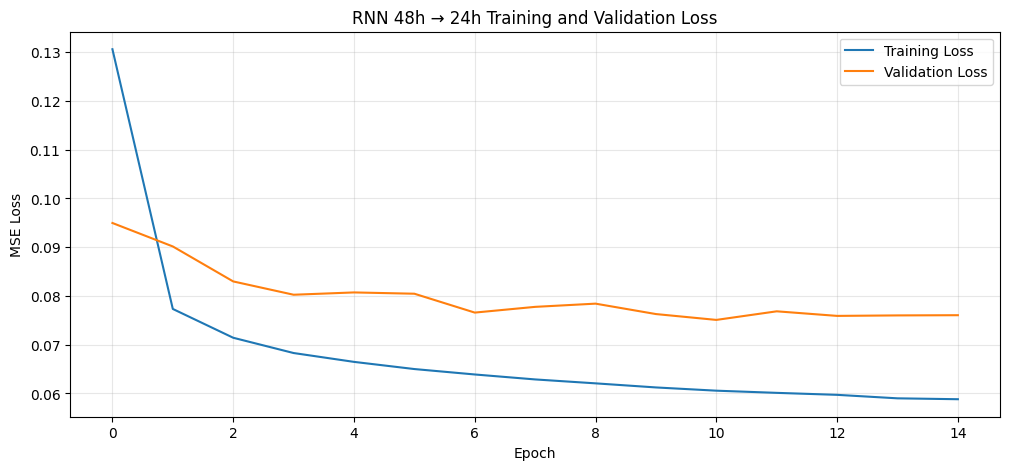

In [18]:
plt.figure(figsize=(12, 5))

plt.plot(
    rnn_history_48.history["loss"],
    label="Training Loss"
)

plt.plot(
    rnn_history_48.history["val_loss"],
    label="Validation Loss"
)

plt.title("RNN 48h → 24h Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    "images/phase5_rnn_48h_training.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [19]:
rnn_pred = target_scaler.inverse_transform(
    rnn_pred_scaled.reshape(-1, 1)
).reshape(rnn_pred_scaled.shape)

rnn_actual = target_scaler.inverse_transform(
    y_test_seq.reshape(-1, 1)
).reshape(y_test_seq.shape)

In [20]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

rnn_mae = mean_absolute_error(
    rnn_actual.flatten(),
    rnn_pred.flatten()
)

rnn_rmse = np.sqrt(
    mean_squared_error(
        rnn_actual.flatten(),
        rnn_pred.flatten()
    )
)

actual_flat = rnn_actual.flatten()
pred_flat = rnn_pred.flatten()

non_zero = actual_flat != 0

rnn_mape = np.mean(
    np.abs(
        (actual_flat[non_zero] - pred_flat[non_zero])
        / actual_flat[non_zero]
    )
) * 100

rnn_r2 = r2_score(
    actual_flat,
    pred_flat
)

rnn_bias = np.mean(
    pred_flat - actual_flat
)


# ------------------------------------------------------------
# 9. RESULTS
# ------------------------------------------------------------

print("========== RNN 48h → 24h RESULTS ==========")
print("MAE :", rnn_mae)
print("RMSE:", rnn_rmse)
print("MAPE:", rnn_mape)
print("R²  :", rnn_r2)
print("Bias:", rnn_bias)

========== RNN 48h → 24h RESULTS ==========
MAE : 1427.2834003407318
RMSE: 1991.721144824708
MAPE: 4.540930505018163
R²  : 0.9044796664275151
Bias: 291.56365410125966


In [21]:
rnn_model_48.save(
    "models/phase5/rnn_48h_to_24h.keras"
)

In [22]:
import json

with open("models/phase5/rnn_48h_to_24h.json", "w") as f:
    json.dump(rnn_history_48.history, f)

**Lstm**

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [24]:
lstm_48_model = Sequential([

    LSTM(
        64,
        input_shape=(48, X_train_seq.shape[2]),
        return_sequences=False
    ),

    Dense(64, activation="relu"),

    Dense(24)
])
lstm_48_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

lstm_48_model.summary()



/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        20,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,200 (102.34 KB)

 Trainable params: 26,200 (102.34 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
lstm_48_history = lstm_48_model.fit(

    X_train_seq,
    y_train_seq,

    validation_data=(
        X_val_seq,
        y_val_seq
    ),

    epochs=15,

    batch_size=64,

    verbose=1
)

Epoch 1/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 0.1136 - mae: 0.2383 - val_loss: 0.0889 - val_mae: 0.2193
Epoch 2/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 0.0692 - mae: 0.1885 - val_loss: 0.0793 - val_mae: 0.2022
Epoch 3/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 0.0637 - mae: 0.1797 - val_loss: 0.0814 - val_mae: 0.2046
Epoch 4/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 0.0598 - mae: 0.1735 - val_loss: 0.0771 - val_mae: 0.1984
Epoch 5/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 0.0570 - mae: 0.1692 - val_loss: 0.0775 - val_mae: 0.1971
Epoch 6/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 0.0544 - mae: 0.1656 - val_loss: 0.0820 - val_mae: 0.2042
Epoch 7/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 0.0518 - mae: 0.1616 - val_loss: 0.0831 - val_mae: 0.2005
Epoch 8/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 0.0492 - mae: 0.1581 - val_loss: 0.0812 - val_mae: 0.2015
Epoch 9/15
1588/1588 ━━━━━━━━━━━

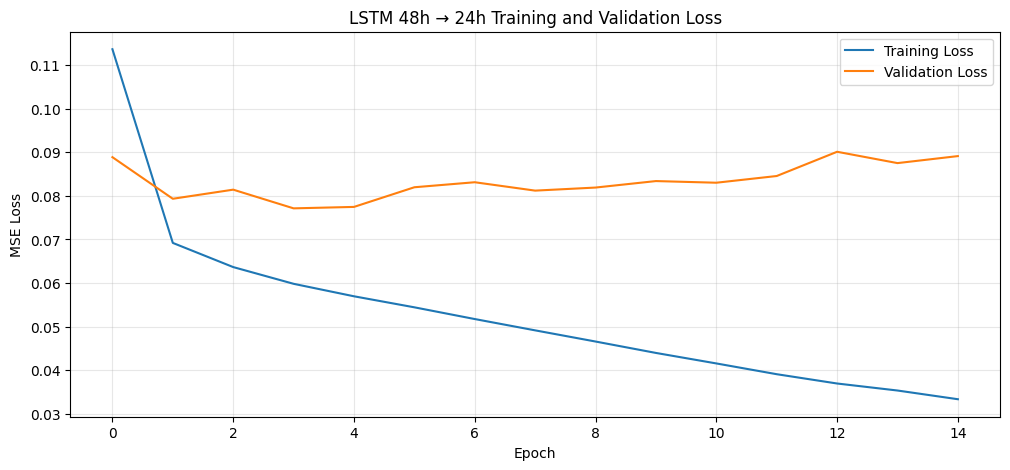

In [26]:
plt.figure(figsize=(12, 5))

plt.plot(
    lstm_48_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    lstm_48_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("LSTM 48h → 24h Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    "images/phase5_lstm_48h_training.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [27]:
lstm_48_pred_scaled = lstm_48_model.predict(
    X_test_seq,
    batch_size=64
)

print(
    "Prediction shape:",
    lstm_48_pred_scaled.shape
)

340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Prediction shape: (21713, 24)


In [28]:
lstm_48_pred = target_scaler.inverse_transform(
    lstm_48_pred_scaled.reshape(-1, 1)
).reshape(lstm_48_pred_scaled.shape)

lstm_48_actual = target_scaler.inverse_transform(
    y_test_seq.reshape(-1, 1)
).reshape(y_test_seq.shape)

In [29]:
actual_flat = lstm_48_actual.flatten()
pred_flat = lstm_48_pred.flatten()

lstm_48_mae = mean_absolute_error(
    actual_flat,
    pred_flat
)

lstm_48_rmse = np.sqrt(
    mean_squared_error(
        actual_flat,
        pred_flat
    )
)

non_zero = actual_flat != 0

lstm_48_mape = np.mean(
    np.abs(
        (actual_flat[non_zero] - pred_flat[non_zero])
        / actual_flat[non_zero]
    )
) * 100

lstm_48_r2 = r2_score(
    actual_flat,
    pred_flat
)

lstm_48_bias = np.mean(
    pred_flat - actual_flat
)


# ============================================================
# 9. RESULTS
# ============================================================

print("========== LSTM 48h → 24h RESULTS ==========")
print("MAE :", lstm_48_mae)
print("RMSE:", lstm_48_rmse)
print("MAPE:", lstm_48_mape)
print("R²  :", lstm_48_r2)
print("Bias:", lstm_48_bias)

========== LSTM 48h → 24h RESULTS ==========
MAE : 1480.8368071696918
RMSE: 2166.632234680274
MAPE: 4.637196960894945
R²  : 0.8869659827518424
Bias: 244.60307681727969


In [30]:
lstm_48_model.save(
    "models/phase5/lstm_48h_to_24h.keras"
)


In [31]:
import json

with open("models/phase5/lstm_48h_to_24h.json", "w") as f:
    json.dump(lstm_48_history.history, f)

**GRU**

In [32]:
from tensorflow.keras.layers import GRU, Dense

In [33]:
gru_48_model = Sequential([

    GRU(
        64,
        input_shape=(48, X_train_seq.shape[2]),
        return_sequences=False
    ),

    Dense(64, activation="relu"),

    Dense(24)
])
gru_48_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

gru_48_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        15,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,272 (83.09 KB)

 Trainable params: 21,272 (83.09 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
gru_48_history = gru_48_model.fit(

    X_train_seq,
    y_train_seq,

    validation_data=(
        X_val_seq,
        y_val_seq
    ),

    epochs=15,

    batch_size=64,

    verbose=1
)


Epoch 1/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 0.1199 - mae: 0.2470 - val_loss: 0.0893 - val_mae: 0.2181
Epoch 2/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 0.0725 - mae: 0.1932 - val_loss: 0.0807 - val_mae: 0.2018
Epoch 3/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 0.0664 - mae: 0.1832 - val_loss: 0.0796 - val_mae: 0.2029
Epoch 4/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 0.0627 - mae: 0.1771 - val_loss: 0.0765 - val_mae: 0.1989
Epoch 5/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 0.0604 - mae: 0.1733 - val_loss: 0.0738 - val_mae: 0.1935
Epoch 6/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 0.0585 - mae: 0.1702 - val_loss: 0.0773 - val_mae: 0.1986
Epoch 7/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 0.0568 - mae: 0.1675 - val_loss: 0.0733 - val_mae: 0.1927
Epoch 8/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 0.0552 - mae: 0.1650 - val_loss: 0.0755 - val_mae: 0.1930
Epoch 9/15
1588/1588 ━━━━━━━━━━━

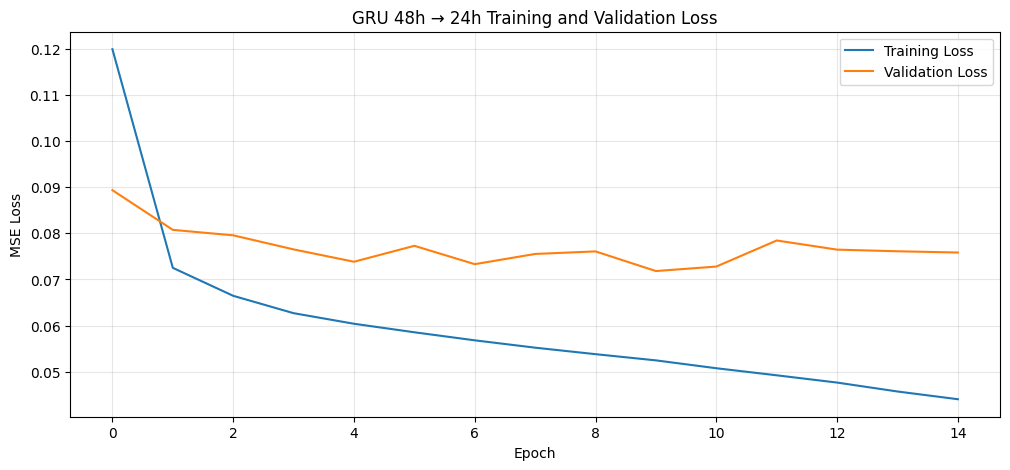

In [35]:
plt.figure(figsize=(12, 5))

plt.plot(
    gru_48_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    gru_48_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("GRU 48h → 24h Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    "images/phase5_gru_48h_training.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [36]:
gru_48_pred_scaled = gru_48_model.predict(
    X_test_seq,
    batch_size=64
)

print(
    "Prediction shape:",
    gru_48_pred_scaled.shape
)


340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Prediction shape: (21713, 24)


In [37]:
gru_48_pred = target_scaler.inverse_transform(
    gru_48_pred_scaled.reshape(-1, 1)
).reshape(gru_48_pred_scaled.shape)

gru_48_actual = target_scaler.inverse_transform(
    y_test_seq.reshape(-1, 1)
).reshape(y_test_seq.shape)

In [38]:
actual_flat = gru_48_actual.flatten()
pred_flat = gru_48_pred.flatten()

gru_48_mae = mean_absolute_error(
    actual_flat,
    pred_flat
)

gru_48_rmse = np.sqrt(
    mean_squared_error(
        actual_flat,
        pred_flat
    )
)

non_zero = actual_flat != 0

gru_48_mape = np.mean(
    np.abs(
        (actual_flat[non_zero] - pred_flat[non_zero])
        / actual_flat[non_zero]
    )
) * 100

gru_48_r2 = r2_score(
    actual_flat,
    pred_flat
)

gru_48_bias = np.mean(
    pred_flat - actual_flat
)


# ============================================================
# 9. RESULTS
# ============================================================

print("========== GRU 48h → 24h RESULTS ==========")
print("MAE :", gru_48_mae)
print("RMSE:", gru_48_rmse)
print("MAPE:", gru_48_mape)
print("R²  :", gru_48_r2)
print("Bias:", gru_48_bias)

========== GRU 48h → 24h RESULTS ==========
MAE : 1408.3473658666167
RMSE: 2007.9125428794946
MAPE: 4.42447204482822
R²  : 0.902920317414255
Bias: 130.56038532518562


In [39]:
gru_48_model.save(
    "models/phase5/gru_48h_to_24h.keras"
)

print("\nGRU 48h → 24h model saved.")


GRU 48h → 24h model saved.


In [40]:
import json

with open("models/phase5/gru_48h_to_24h.json", "w") as f:
    json.dump(gru_48_history.history, f)

**Bi - LSTM**

In [41]:
from tensorflow.keras.layers import Bidirectional, LSTM, Dense


In [42]:
bilstm_48_model = Sequential([

    Bidirectional(
        LSTM(
            64,
            return_sequences=False
        ),
        input_shape=(48, X_train_seq.shape[2])
    ),

    Dense(64, activation="relu"),

    Dense(24)
])
bilstm_48_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

bilstm_48_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 128)            │        40,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,776 (198.34 KB)

 Trainable params: 50,776 (198.34 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
bilstm_48_history = bilstm_48_model.fit(

    X_train_seq,
    y_train_seq,

    validation_data=(
        X_val_seq,
        y_val_seq
    ),

    epochs=15,

    batch_size=64,

    verbose=1
)

Epoch 1/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - loss: 0.1059 - mae: 0.2295 - val_loss: 0.0886 - val_mae: 0.2162
Epoch 2/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 0.0657 - mae: 0.1832 - val_loss: 0.0818 - val_mae: 0.2065
Epoch 3/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 0.0595 - mae: 0.1735 - val_loss: 0.0779 - val_mae: 0.1987
Epoch 4/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - loss: 0.0546 - mae: 0.1660 - val_loss: 0.0788 - val_mae: 0.1987
Epoch 5/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 0.0497 - mae: 0.1592 - val_loss: 0.0795 - val_mae: 0.1965
Epoch 6/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 0.0453 - mae: 0.1531 - val_loss: 0.0804 - val_mae: 0.1988
Epoch 7/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 0.0408 - mae: 0.1465 - val_loss: 0.0832 - val_mae: 0.2018
Epoch 8/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - loss: 0.0365 - mae: 0.1398 - val_loss: 0.0892 - val_mae: 0.2072
Epoch 9/15
1588/1588 ━━━

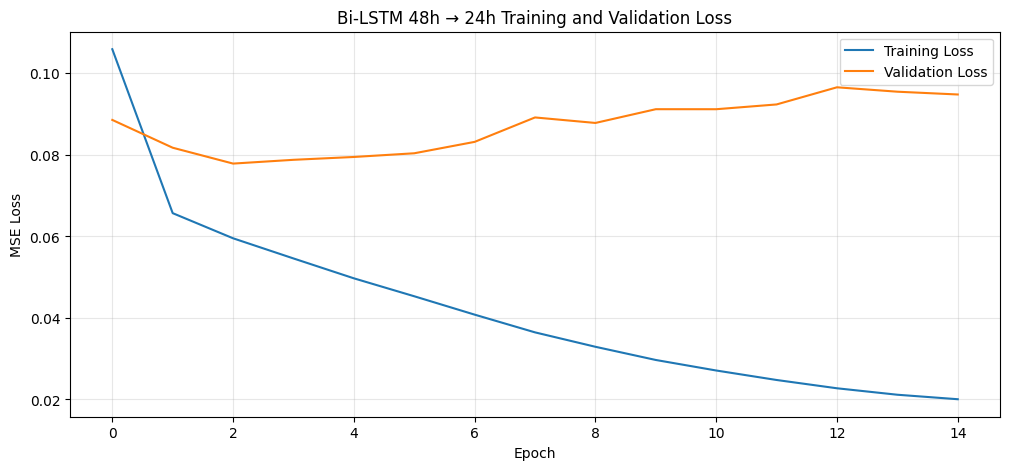

In [44]:
plt.figure(figsize=(12, 5))

plt.plot(
    bilstm_48_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    bilstm_48_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Bi-LSTM 48h → 24h Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    "images/phase5_bilstm_48h_training.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [45]:
bilstm_48_pred_scaled = bilstm_48_model.predict(
    X_test_seq,
    batch_size=64
)

print(
    "Prediction shape:",
    bilstm_48_pred_scaled.shape
)

340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Prediction shape: (21713, 24)


In [46]:
bilstm_48_pred = target_scaler.inverse_transform(
    bilstm_48_pred_scaled.reshape(-1, 1)
).reshape(bilstm_48_pred_scaled.shape)

bilstm_48_actual = target_scaler.inverse_transform(
    y_test_seq.reshape(-1, 1)
).reshape(y_test_seq.shape)

In [47]:
actual_flat = bilstm_48_actual.flatten()
pred_flat = bilstm_48_pred.flatten()

bilstm_48_mae = mean_absolute_error(
    actual_flat,
    pred_flat
)

bilstm_48_rmse = np.sqrt(
    mean_squared_error(
        actual_flat,
        pred_flat
    )
)

non_zero = actual_flat != 0

bilstm_48_mape = np.mean(
    np.abs(
        (actual_flat[non_zero] - pred_flat[non_zero])
        / actual_flat[non_zero]
    )
) * 100

bilstm_48_r2 = r2_score(
    actual_flat,
    pred_flat
)

bilstm_48_bias = np.mean(
    pred_flat - actual_flat
)


# ============================================================
# 9. RESULTS
# ============================================================

print("========== BI-LSTM 48h → 24h RESULTS ==========")
print("MAE :", bilstm_48_mae)
print("RMSE:", bilstm_48_rmse)
print("MAPE:", bilstm_48_mape)
print("R²  :", bilstm_48_r2)
print("Bias:", bilstm_48_bias)

========== BI-LSTM 48h → 24h RESULTS ==========
MAE : 1582.6344591814595
RMSE: 2276.95754794763
MAPE: 4.940600257325572
R²  : 0.8751614747425135
Bias: 128.43057508510645


In [48]:
bilstm_48_model.save(
    "models/phase5/bilstm_48h_to_24h.keras"
)

print("\nBi-LSTM 48h → 24h model saved.")


Bi-LSTM 48h → 24h model saved.


In [49]:
import json

with open("models/phase5/bilstm_48h_to_24h.json", "w") as f:
    json.dump(bilstm_48_history.history, f)

# 24 Hours -- 24

In [50]:
def create_sequences(X, y, input_steps=24, output_steps=24):

    X_seq = []
    y_seq = []

    for i in range(input_steps, len(X) - output_steps + 1):

        X_seq.append(
            X[i-input_steps:i]
        )

        y_seq.append(
            y[i:i+output_steps].flatten()
        )

    return np.array(X_seq), np.array(y_seq)


X_train_seq, y_train_seq = create_sequences(
    X_train_scaled,
    y_train_scaled,
    input_steps=24,
    output_steps=24
)

X_val_seq, y_val_seq = create_sequences(
    X_val_scaled,
    y_val_scaled,
    input_steps=24,
    output_steps=24
)

X_test_seq, y_test_seq = create_sequences(
    X_test_scaled,
    y_test_scaled,
    input_steps=24,
    output_steps=24
)


print("X_train:", X_train_seq.shape)
print("y_train:", y_train_seq.shape)

print("X_val:", X_val_seq.shape)
print("y_val:", y_val_seq.shape)

print("X_test:", X_test_seq.shape)
print("y_test:", y_test_seq.shape)

X_train: (101609, 24, 15)
y_train: (101609, 24)
X_val: (21737, 24, 15)
y_val: (21737, 24)
X_test: (21737, 24, 15)
y_test: (21737, 24)


In [51]:
rnn_24_model = Sequential([

    SimpleRNN(
        64,
        input_shape=(24, X_train_seq.shape[2]),
        return_sequences=False
    ),

    Dense(64, activation="relu"),

    Dense(24)
])
rnn_24_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

rnn_24_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,840 (42.34 KB)

 Trainable params: 10,840 (42.34 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:
rnn_24_history = rnn_24_model.fit(

    X_train_seq,
    y_train_seq,

    validation_data=(
        X_val_seq,
        y_val_seq
    ),

    epochs=15,

    batch_size=64,

    verbose=1
)

Epoch 1/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 0.1295 - mae: 0.2588 - val_loss: 0.0942 - val_mae: 0.2250
Epoch 2/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.0788 - mae: 0.2029 - val_loss: 0.0849 - val_mae: 0.2100
Epoch 3/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.0722 - mae: 0.1923 - val_loss: 0.0841 - val_mae: 0.2120
Epoch 4/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.0691 - mae: 0.1870 - val_loss: 0.0803 - val_mae: 0.2003
Epoch 5/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.0670 - mae: 0.1835 - val_loss: 0.0773 - val_mae: 0.1974
Epoch 6/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 0.0655 - mae: 0.1807 - val_loss: 0.0809 - val_mae: 0.2051
Epoch 7/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.0643 - mae: 0.1788 - val_loss: 0.0763 - val_mae: 0.1954
Epoch 8/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.0632 - mae: 0.1771 - val_loss: 0.0758 - val_mae: 0.1963
Epoch 9/15
1588/1588 ━━━━━━━━━━━━━━━

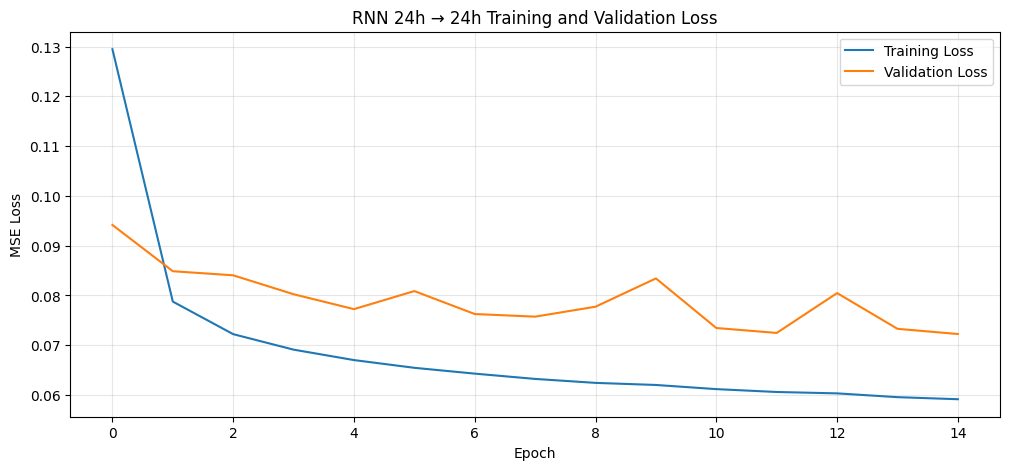

In [53]:
plt.figure(figsize=(12, 5))

plt.plot(
    rnn_24_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    rnn_24_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("RNN 24h → 24h Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    "images/phase5_rnn_24h_training.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [54]:
rnn_24_pred_scaled = rnn_24_model.predict(
    X_test_seq,
    batch_size=64
)

print(
    "Prediction shape:",
    rnn_24_pred_scaled.shape
)

340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Prediction shape: (21737, 24)


In [55]:
rnn_24_pred = target_scaler.inverse_transform(
    rnn_24_pred_scaled.reshape(-1, 1)
).reshape(rnn_24_pred_scaled.shape)

rnn_24_actual = target_scaler.inverse_transform(
    y_test_seq.reshape(-1, 1)
).reshape(y_test_seq.shape)

In [56]:
actual_flat = rnn_24_actual.flatten()
pred_flat = rnn_24_pred.flatten()

rnn_24_mae = mean_absolute_error(
    actual_flat,
    pred_flat
)

rnn_24_rmse = np.sqrt(
    mean_squared_error(
        actual_flat,
        pred_flat
    )
)

non_zero = actual_flat != 0

rnn_24_mape = np.mean(
    np.abs(
        (actual_flat[non_zero] - pred_flat[non_zero])
        / actual_flat[non_zero]
    )
) * 100

rnn_24_r2 = r2_score(
    actual_flat,
    pred_flat
)

rnn_24_bias = np.mean(
    pred_flat - actual_flat
)


# ============================================================
# 9. RESULTS
# ============================================================

print("========== RNN 24h → 24h RESULTS ==========")
print("MAE :", rnn_24_mae)
print("RMSE:", rnn_24_rmse)
print("MAPE:", rnn_24_mape)
print("R²  :", rnn_24_r2)
print("Bias:", rnn_24_bias)

========== RNN 24h → 24h RESULTS ==========
MAE : 1376.7156520411265
RMSE: 1926.8904657690284
MAPE: 4.347443014548393
R²  : 0.9105399990964322
Bias: 78.35691115307425


In [57]:
rnn_24_model.save(
    "models/phase5/rnn_24h_to_24h.keras"
)

In [58]:
import json

with open("models/phase5/rnn_24h_to_24h.json", "w") as f:
    json.dump(rnn_24_history.history, f)

**Lstm**

In [59]:
from tensorflow.keras.layers import LSTM, Dense

In [60]:
lstm_24_model = Sequential([

    LSTM(
        64,
        input_shape=(24, X_train_seq.shape[2]),
        return_sequences=False
    ),

    Dense(64, activation="relu"),

    Dense(24)
])
lstm_24_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

lstm_24_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 64)             │        20,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,200 (102.34 KB)

 Trainable params: 26,200 (102.34 KB)

 Non-trainable params: 0 (0.00 B)

In [61]:
lstm_24_history = lstm_24_model.fit(

    X_train_seq,
    y_train_seq,

    validation_data=(
        X_val_seq,
        y_val_seq
    ),

    epochs=15,

    batch_size=64,

    verbose=1
)

Epoch 1/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 0.1166 - mae: 0.2409 - val_loss: 0.0861 - val_mae: 0.2156
Epoch 2/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 0.0698 - mae: 0.1891 - val_loss: 0.0813 - val_mae: 0.2072
Epoch 3/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 0.0649 - mae: 0.1809 - val_loss: 0.0788 - val_mae: 0.2021
Epoch 4/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 0.0612 - mae: 0.1747 - val_loss: 0.0779 - val_mae: 0.1978
Epoch 5/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - loss: 0.0585 - mae: 0.1706 - val_loss: 0.0778 - val_mae: 0.2005
Epoch 6/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - loss: 0.0560 - mae: 0.1668 - val_loss: 0.0786 - val_mae: 0.2021
Epoch 7/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - loss: 0.0539 - mae: 0.1638 - val_loss: 0.0750 - val_mae: 0.1946
Epoch 8/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 0.0517 - mae: 0.1606 - val_loss: 0.0812 - val_mae: 0.2018
Epoch 9/15
1588/1588 ━━━━━━━

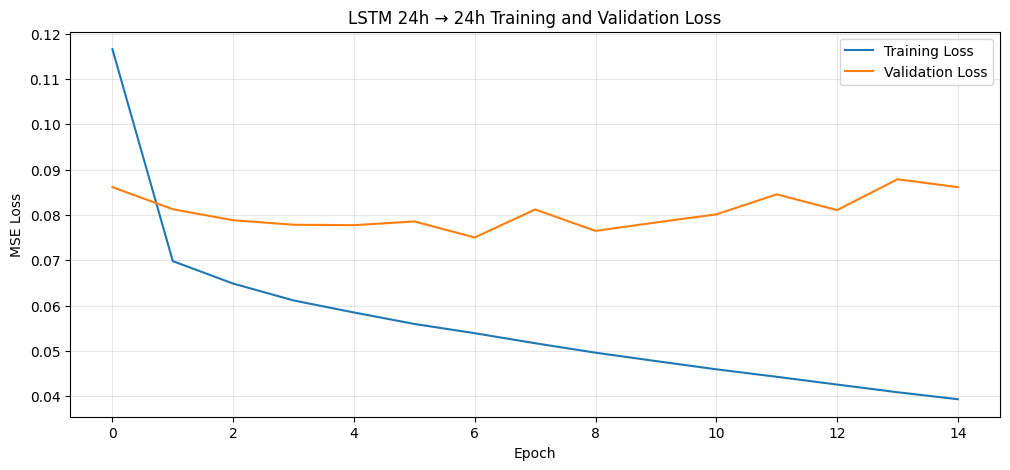

In [63]:
plt.figure(figsize=(12, 5))

plt.plot(
    lstm_24_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    lstm_24_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("LSTM 24h → 24h Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    "images/phase5_lstm_24h_training.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [64]:
lstm_24_pred_scaled = lstm_24_model.predict(
    X_test_seq,
    batch_size=64
)

print(
    "Prediction shape:",
    lstm_24_pred_scaled.shape
)

340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Prediction shape: (21737, 24)


In [65]:
lstm_24_pred = target_scaler.inverse_transform(
    lstm_24_pred_scaled.reshape(-1, 1)
).reshape(lstm_24_pred_scaled.shape)

lstm_24_actual = target_scaler.inverse_transform(
    y_test_seq.reshape(-1, 1)
).reshape(y_test_seq.shape)

In [66]:
actual_flat = lstm_24_actual.flatten()
pred_flat = lstm_24_pred.flatten()

lstm_24_mae = mean_absolute_error(
    actual_flat,
    pred_flat
)

lstm_24_rmse = np.sqrt(
    mean_squared_error(
        actual_flat,
        pred_flat
    )
)

non_zero = actual_flat != 0

lstm_24_mape = np.mean(
    np.abs(
        (actual_flat[non_zero] - pred_flat[non_zero])
        / actual_flat[non_zero]
    )
) * 100

lstm_24_r2 = r2_score(
    actual_flat,
    pred_flat
)

lstm_24_bias = np.mean(
    pred_flat - actual_flat
)


# ============================================================
# 9. RESULTS
# ============================================================

print("========== LSTM 24h → 24h RESULTS ==========")
print("MAE :", lstm_24_mae)
print("RMSE:", lstm_24_rmse)
print("MAPE:", lstm_24_mape)
print("R²  :", lstm_24_r2)
print("Bias:", lstm_24_bias)

========== LSTM 24h → 24h RESULTS ==========
MAE : 1491.6327254665684
RMSE: 2165.564133063436
MAPE: 4.693110195238567
R²  : 0.8870055943155081
Bias: 315.4325268070607


In [67]:
lstm_24_model.save(
    "models/phase5/lstm_24h_to_24h.keras"
)

In [68]:
import json

with open("models/phase5/lstm_24h_to_24h.json", "w") as f:
    json.dump(lstm_24_history.history, f)

**GRU**

In [69]:
from tensorflow.keras.layers import GRU, Dense

In [71]:
gru_24_model = Sequential([

    GRU(
        64,
        input_shape=(24, X_train_seq.shape[2]),
        return_sequences=False
    ),

    Dense(64, activation="relu"),

    Dense(24)
])
gru_24_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

gru_24_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 64)             │        15,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,272 (83.09 KB)

 Trainable params: 21,272 (83.09 KB)

 Non-trainable params: 0 (0.00 B)

In [72]:
gru_24_history = gru_24_model.fit(

    X_train_seq,
    y_train_seq,

    validation_data=(
        X_val_seq,
        y_val_seq
    ),

    epochs=15,

    batch_size=64,

    verbose=1
)

Epoch 1/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 0.1184 - mae: 0.2452 - val_loss: 0.0875 - val_mae: 0.2146
Epoch 2/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 0.0722 - mae: 0.1932 - val_loss: 0.0838 - val_mae: 0.2088
Epoch 3/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 0.0665 - mae: 0.1838 - val_loss: 0.0794 - val_mae: 0.2000
Epoch 4/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 0.0630 - mae: 0.1781 - val_loss: 0.0768 - val_mae: 0.1976
Epoch 5/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 0.0607 - mae: 0.1742 - val_loss: 0.0753 - val_mae: 0.1939
Epoch 6/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 0.0588 - mae: 0.1711 - val_loss: 0.0795 - val_mae: 0.2009
Epoch 7/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 0.0572 - mae: 0.1683 - val_loss: 0.0737 - val_mae: 0.1906
Epoch 8/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 29s 7ms/step - loss: 0.0556 - mae: 0.1660 - val_loss: 0.0744 - val_mae: 0.1948
Epoch 9/15
1588/1588 ━━━━━━━━━━

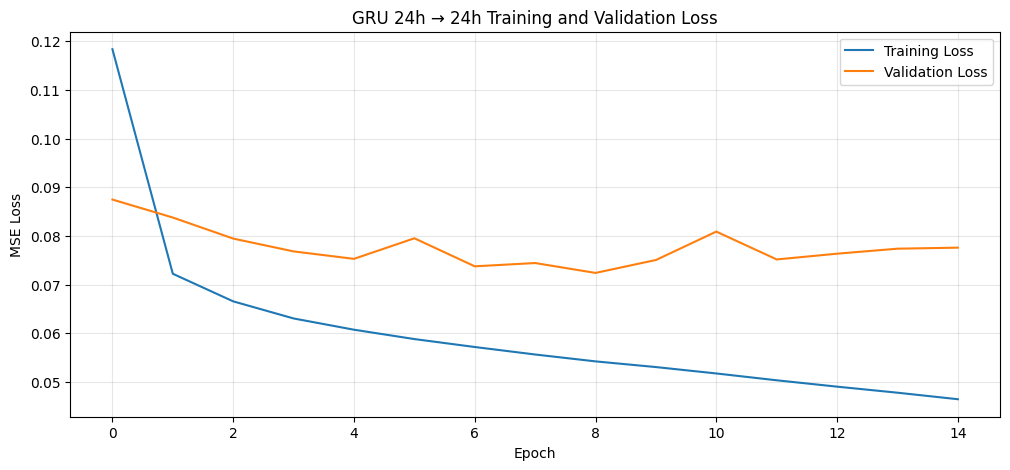

In [73]:
plt.figure(figsize=(12, 5))

plt.plot(
    gru_24_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    gru_24_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("GRU 24h → 24h Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    "images/phase5_gru_24h_training.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



In [74]:
gru_24_pred_scaled = gru_24_model.predict(
    X_test_seq,
    batch_size=64
)

print(
    "Prediction shape:",
    gru_24_pred_scaled.shape
)

340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Prediction shape: (21737, 24)


In [75]:
gru_24_pred = target_scaler.inverse_transform(
    gru_24_pred_scaled.reshape(-1, 1)
).reshape(gru_24_pred_scaled.shape)

gru_24_actual = target_scaler.inverse_transform(
    y_test_seq.reshape(-1, 1)
).reshape(y_test_seq.shape)

In [76]:
actual_flat = gru_24_actual.flatten()
pred_flat = gru_24_pred.flatten()

gru_24_mae = mean_absolute_error(
    actual_flat,
    pred_flat
)

gru_24_rmse = np.sqrt(
    mean_squared_error(
        actual_flat,
        pred_flat
    )
)

non_zero = actual_flat != 0

gru_24_mape = np.mean(
    np.abs(
        (actual_flat[non_zero] - pred_flat[non_zero])
        / actual_flat[non_zero]
    )
) * 100

gru_24_r2 = r2_score(
    actual_flat,
    pred_flat
)

gru_24_bias = np.mean(
    pred_flat - actual_flat
)


# ============================================================
# 9. RESULTS
# ============================================================

print("========== GRU 24h → 24h RESULTS ==========")
print("MAE :", gru_24_mae)
print("RMSE:", gru_24_rmse)
print("MAPE:", gru_24_mape)
print("R²  :", gru_24_r2)
print("Bias:", gru_24_bias)

========== GRU 24h → 24h RESULTS ==========
MAE : 1429.7045531539566
RMSE: 2086.4722667763826
MAPE: 4.502954834750559
R²  : 0.8951085532823124
Bias: 241.54513742379305


In [77]:
gru_24_model.save(
    "models/phase5/gru_24h_to_24h.keras"
)

In [78]:
import json

with open("models/phase5/gru_24h_to_24h.json", "w") as f:
    json.dump(gru_24_history.history, f)

**Bidirectional LSTM**

In [79]:
from tensorflow.keras.layers import Bidirectional, LSTM, Dense


In [80]:
bilstm_24_model = Sequential([

    Bidirectional(
        LSTM(
            64,
            return_sequences=False
        ),
        input_shape=(24, X_train_seq.shape[2])
    ),

    Dense(64, activation="relu"),

    Dense(24)
])

bilstm_24_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

bilstm_24_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        40,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,776 (198.34 KB)

 Trainable params: 50,776 (198.34 KB)

 Non-trainable params: 0 (0.00 B)

In [81]:
bilstm_24_history = bilstm_24_model.fit(

    X_train_seq,
    y_train_seq,

    validation_data=(
        X_val_seq,
        y_val_seq
    ),

    epochs=15,

    batch_size=64,

    verbose=1
)

Epoch 1/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 0.1049 - mae: 0.2298 - val_loss: 0.0871 - val_mae: 0.2111
Epoch 2/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 0.0672 - mae: 0.1854 - val_loss: 0.0821 - val_mae: 0.2092
Epoch 3/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - loss: 0.0608 - mae: 0.1754 - val_loss: 0.0760 - val_mae: 0.1994
Epoch 4/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 0.0563 - mae: 0.1682 - val_loss: 0.0789 - val_mae: 0.2007
Epoch 5/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - loss: 0.0526 - mae: 0.1626 - val_loss: 0.0753 - val_mae: 0.1926
Epoch 6/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - loss: 0.0489 - mae: 0.1571 - val_loss: 0.0772 - val_mae: 0.1968
Epoch 7/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 0.0457 - mae: 0.1525 - val_loss: 0.0797 - val_mae: 0.2006
Epoch 8/15
1588/1588 ━━━━━━━━━━━━━━━━━━━━ 34s 10ms/step - loss: 0.0426 - mae: 0.1477 - val_loss: 0.0828 - val_mae: 0.2011
Epoch 9/15
1588/1588 ━━━━

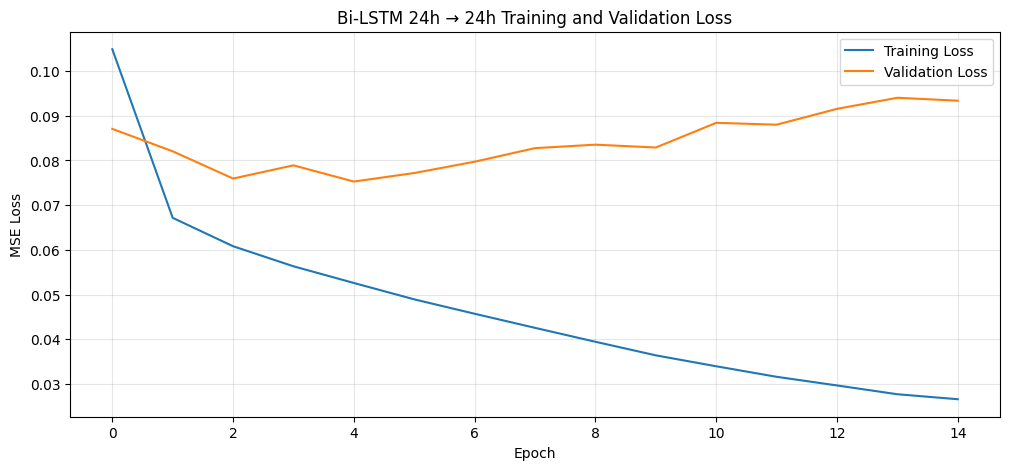

In [82]:
plt.figure(figsize=(12, 5))

plt.plot(
    bilstm_24_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    bilstm_24_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Bi-LSTM 24h → 24h Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    "images/phase5_bilstm_24h_training.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [83]:
bilstm_24_pred_scaled = bilstm_24_model.predict(
    X_test_seq,
    batch_size=64
)

print(
    "Prediction shape:",
    bilstm_24_pred_scaled.shape
)

340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Prediction shape: (21737, 24)


In [84]:
bilstm_24_pred = target_scaler.inverse_transform(
    bilstm_24_pred_scaled.reshape(-1, 1)
).reshape(bilstm_24_pred_scaled.shape)

bilstm_24_actual = target_scaler.inverse_transform(
    y_test_seq.reshape(-1, 1)
).reshape(y_test_seq.shape)

In [85]:
actual_flat = bilstm_24_actual.flatten()
pred_flat = bilstm_24_pred.flatten()

bilstm_24_mae = mean_absolute_error(
    actual_flat,
    pred_flat
)

bilstm_24_rmse = np.sqrt(
    mean_squared_error(
        actual_flat,
        pred_flat
    )
)

non_zero = actual_flat != 0

bilstm_24_mape = np.mean(
    np.abs(
        (actual_flat[non_zero] - pred_flat[non_zero])
        / actual_flat[non_zero]
    )
) * 100

bilstm_24_r2 = r2_score(
    actual_flat,
    pred_flat
)

bilstm_24_bias = np.mean(
    pred_flat - actual_flat
)


# ============================================================
# 9. RESULTS
# ============================================================

print("========== BI-LSTM 24h → 24h RESULTS ==========")
print("MAE :", bilstm_24_mae)
print("RMSE:", bilstm_24_rmse)
print("MAPE:", bilstm_24_mape)
print("R²  :", bilstm_24_r2)
print("Bias:", bilstm_24_bias)

========== BI-LSTM 24h → 24h RESULTS ==========
MAE : 1532.417936871062
RMSE: 2220.760734914259
MAPE: 4.8294873430028
R²  : 0.8811721107591479
Bias: 225.46354399908927


In [86]:
bilstm_24_model.save(
    "models/phase5/bilstm_24h_to_24h.keras"
)

In [87]:
import json

with open("models/phase5/bilstm_24h_to_24h.json", "w") as f:
    json.dump(bilstm_24_history.history, f)

In [88]:
import pandas as pd

phase5_results = []

phase5_results.append([
    "RNN", 24, 24, 1376.7156520411265, 1926.8904657690284,
    4.347443014548393, 0.9105399990964322, 78.35691115307425
])

phase5_results.append([
    "GRU", 48, 24, 1408.3473658666167, 2007.9125428794946,
    4.42447204482822, 0.902920317414255, 130.56038532518562
])

phase5_results.append([
    "RNN", 48, 24, 1427.2834003407318, 1991.721144824708,
    4.540930505018163, 0.9044796664275151, 291.56365410125966
])

phase5_results.append([
    "GRU", 24, 24, 1429.7045531539566, 2086.4722667763826,
    4.503, 0.8951, 241.55
])

phase5_results.append([
    "RNN", 168, 24, 1430.2133220007822, 1981.7279488063964,
    4.582684822640543, 0.9053238845459299, 375.384035532258
])

phase5_results.append([
    "GRU", 168, 24, 1452.6757279173771, 2075.132045638438,
    4.598523493680257, 0.8961888896859629, 284.29167971810284
])

phase5_results.append([
    "LSTM", 48, 24, 1480.8368071696918, 2166.632234680274,
    4.637196960894945, 0.8869659827518424, 244.60307681727969
])

phase5_results.append([
    "LSTM", 24, 24, 1491.6327254665684, 2165.564133063436,
    4.693110195238567, 0.8870055943155081, 315.4325268070607
])

phase5_results.append([
    "Bi-LSTM", 24, 24, 1532.42, 2220.76,
    4.829, 0.8812, 225.46
])

phase5_results.append([
    "LSTM", 168, 24, 1539.1091036484686, 2171.0322859555713,
    4.9120441764824285, 0.8863721142778263, 447.83148694518695
])

phase5_results.append([
    "Bi-LSTM", 168, 24, 1557.6657932493313, 2229.9810757314744,
    4.928703239175246, 0.8801177965194642, 369.85794581685906
])

phase5_results.append([
    "Bi-LSTM", 48, 24, 1582.6344591814595, 2276.95754794763,
    4.940600257325572, 0.8751614747425135, 128.43057508510645
])

In [89]:
phase5_df = pd.DataFrame(
    phase5_results,
    columns=[
        "Model",
        "Input_Hours",
        "Output_Hours",
        "MAE",
        "RMSE",
        "MAPE",
        "R2",
        "Bias"
    ]
)

In [90]:
phase5_df = phase5_df.sort_values(
    by="MAE",
    ascending=True
).reset_index(drop=True)

phase5_df.insert(
    0,
    "Rank",
    range(1, len(phase5_df) + 1)
)

In [91]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

display(phase5_df)

,Rank,Model,Input_Hours,Output_Hours,MAE,RMSE,MAPE,R2,Bias
0,1,RNN,24,24,1376.715652,1926.890466,4.347443,0.910540,78.356911
1,2,GRU,48,24,1408.347366,2007.912543,4.424472,0.902920,130.560385
2,3,RNN,48,24,1427.283400,1991.721145,4.540931,0.904480,291.563654
3,4,GRU,24,24,1429.704553,2086.472267,4.503000,0.895100,241.550000
4,5,RNN,168,24,1430.213322,1981.727949,4.582685,0.905324,375.384036
5,6,GRU,168,24,1452.675728,2075.132046,4.598523,0.896189,284.291680
6,7,LSTM,48,24,1480.836807,2166.632235,4.637197,0.886966,244.603077
7,8,LSTM,24,24,1491.632725,2165.564133,4.693110,0.887006,315.432527
8,9,Bi-LSTM,24,24,1532.420000,2220.760000,4.829000,0.881200,225.460000
9,10,LSTM,168,24,1539.109104,2171.032286,4.912044,0.886372,447.831487


In [92]:
phase5_df.to_csv(
    "models/phase5_all_results.csv",
    index=False
)
print("Saved")

Saved
